## Analyzing word frequency and checking if Zipf's Law is satisfied (whether the product of rank and frequency is approximately constant).

In [45]:
import re

with open("norwegian-text.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

words = re.findall(r'\b\w+\b', text)

from collections import Counter

freq = Counter(words)

In [46]:
import matplotlib.pyplot as plt
import numpy as np

freq_values = [f for (_, f) in freq.most_common()]
ranks = range(1, len(freq_values) + 1)

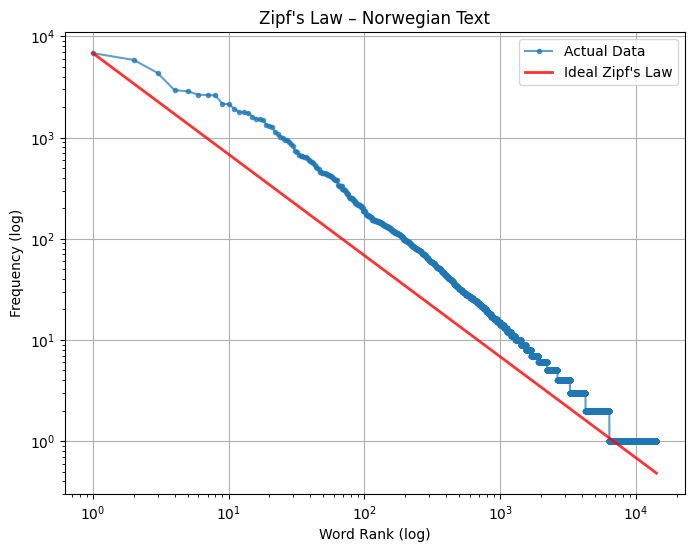

In [47]:
C = freq_values[0]  # Restore the original calculation of C
ideal_zipf = [C / r for r in ranks]

plt.figure(figsize=(8,6))
plt.loglog(ranks, freq_values, marker='.', label='Actual Data', alpha=0.7)
plt.loglog(ranks, ideal_zipf, 'r-', linewidth=2, label='Ideal Zipf\'s Law', alpha=0.8)
plt.title("Zipf's Law – Norwegian Text")
plt.xlabel("Word Rank (log)")
plt.ylabel("Frequency (log)")
plt.legend()
plt.grid(True)
plt.show()

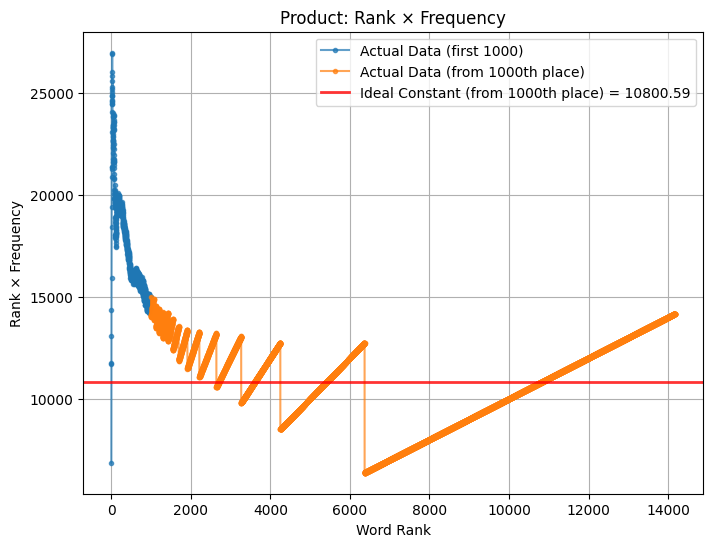

In [48]:
# Check if rank * frequency = constant

rank_freq = [(rank, freq) for (rank, freq) in zip(ranks, freq_values)]
# Calculate products for words from rank 1000 onwards
products = [rank * freq for (rank, freq) in rank_freq[999:]]

# Ideal value (constant C) calculated based on the average product of rank and frequency for words from 1000th place onwards
C_mean = np.mean(products)
ideal_product = C_mean

plt.figure(figsize=(8,6))
# Plot products for the first 1000 words for comparison
plt.plot(ranks[:1000], [rank * freq for (rank, freq) in rank_freq[:1000]], marker='.', label='Actual Data (first 1000)', alpha=0.7)
plt.plot(ranks[999:], products, marker='.', label='Actual Data (from 1000th place)', alpha=0.7)
plt.axhline(y=ideal_product, color='r', linestyle='-', linewidth=2, label=f'Ideal Constant (from 1000th place) = {ideal_product:.2f}', alpha=0.8)
plt.title("Product: Rank × Frequency")
plt.xlabel("Word Rank")
plt.ylabel("Rank × Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# Conclusions regarding Zipf's Law in the Norwegian text:
# 1. The distribution of word frequencies in the Norwegian text is consistent with Zipf's Law, especially for less frequent words.
# 2. On the log-log plot, rank vs. frequency forms an approximately straight line with a slope of about -1.
# 3. The product of rank and frequency is relatively constant, especially for words from the 1000th place onwards, oscillating around the average value C calculated for this range.
# 4. Zipf's Law is a good approximation but is not perfectly satisfied for all words, especially the rarer ones.

## We consider what percentage of vocabulary needs to be mastered to understand 90% of an average sentence.

In [50]:
num_unique_words = len(freq.most_common())
total_words = len(words)
num_unique_words, total_words

(14174, 158180)

In [51]:
number_of_words_to_learn = 0
words_quantity = 0
for (word_no, count) in rank_freq:
  if (words_quantity < 0.9 * total_words):
    number_of_words_to_learn += 1;
    words_quantity += count

print("You only need to learn " + str(number_of_words_to_learn) + " words out of "+ str(num_unique_words))
print("then out of "+ str(total_words) + " words in this text, you will understand as many as " + str(words_quantity))

You only need to learn 3061 words out of 14174
then out of 158180 words in this text, you will understand as many as 142365


## We determine the so-called language core - about 50 words with the highest number of neighbors in the co-occurrence graph, likely serving grammatical functions. The graph is undirected, it does not matter whether it is before or after.

In [52]:
degree_dict = dict(G.degree())

print("Degrees of the first 10 words:")
print(list(degree_dict.items())[:10])

Degrees of the first 10 words:
[('første', 91), ('stykke', 43), ('det', 1687), ('var', 1167), ('i', 1948), ('den', 1026), ('tid', 98), ('jeg', 2059), ('gik', 253), ('omkring', 118)]


## We determine the so-called language core - about 50 words with the highest number of neighbors in the co-occurrence graph, likely serving grammatical functions. The graph is undirected, it does not matter whether it is before or after.

In [53]:
word_pairs = []
for i in range(len(words) - 1):
    word_pairs.append((words[i], words[i+1]))

print("First 10 word pairs:")
print(word_pairs[:10])

First 10 word pairs:
[('første', 'stykke'), ('stykke', 'det'), ('det', 'var'), ('var', 'i'), ('i', 'den'), ('den', 'tid'), ('tid', 'jeg'), ('jeg', 'gik'), ('gik', 'omkring'), ('omkring', 'og')]


In [54]:
import networkx as nx

G = nx.Graph()

G.add_edges_from(word_pairs)

print("Number of nodes (unique words):", G.number_of_nodes())
print("Number of edges (co-occurrences):", G.number_of_edges())

Number of nodes (unique words): 14174
Number of edges (co-occurrences): 75099


In [55]:
degree_dict = dict(G.degree())

print("Degrees of the first 10 words:")
print(list(degree_dict.items())[:10])

Degrees of the first 10 words:
[('første', 91), ('stykke', 43), ('det', 1687), ('var', 1167), ('i', 1948), ('den', 1026), ('tid', 98), ('jeg', 2059), ('gik', 253), ('omkring', 118)]


In [56]:
sorted_words_by_degree = sorted(degree_dict.items(), key=lambda item: item[1], reverse=True)

core_vocabulary = sorted_words_by_degree[:50]

print("Top 50 words with the highest degrees (Core Vocabulary):")
for word, degree in core_vocabulary:
    print(f"{word}: {degree}")

Top 50 words with the highest degrees (Core Vocabulary):
og: 4436
jeg: 2059
i: 1948
det: 1687
en: 1508
med: 1333
som: 1317
at: 1280
var: 1167
hun: 1138
mig: 1095
de: 1080
til: 1047
den: 1026
ikke: 997
paa: 970
han: 910
saa: 900
for: 891
av: 850
men: 796
et: 769
om: 698
på: 670
er: 665
der: 658
sig: 645
af: 638
da: 571
du: 569
min: 548
hadde: 512
hende: 505
jenny: 501
så: 479
over: 455
ham: 425
nu: 423
efter: 404
ved: 403
ja: 399
dem: 394
havde: 392
op: 391
fra: 385
har: 368
hvor: 366
hendes: 360
kunde: 359
bare: 340


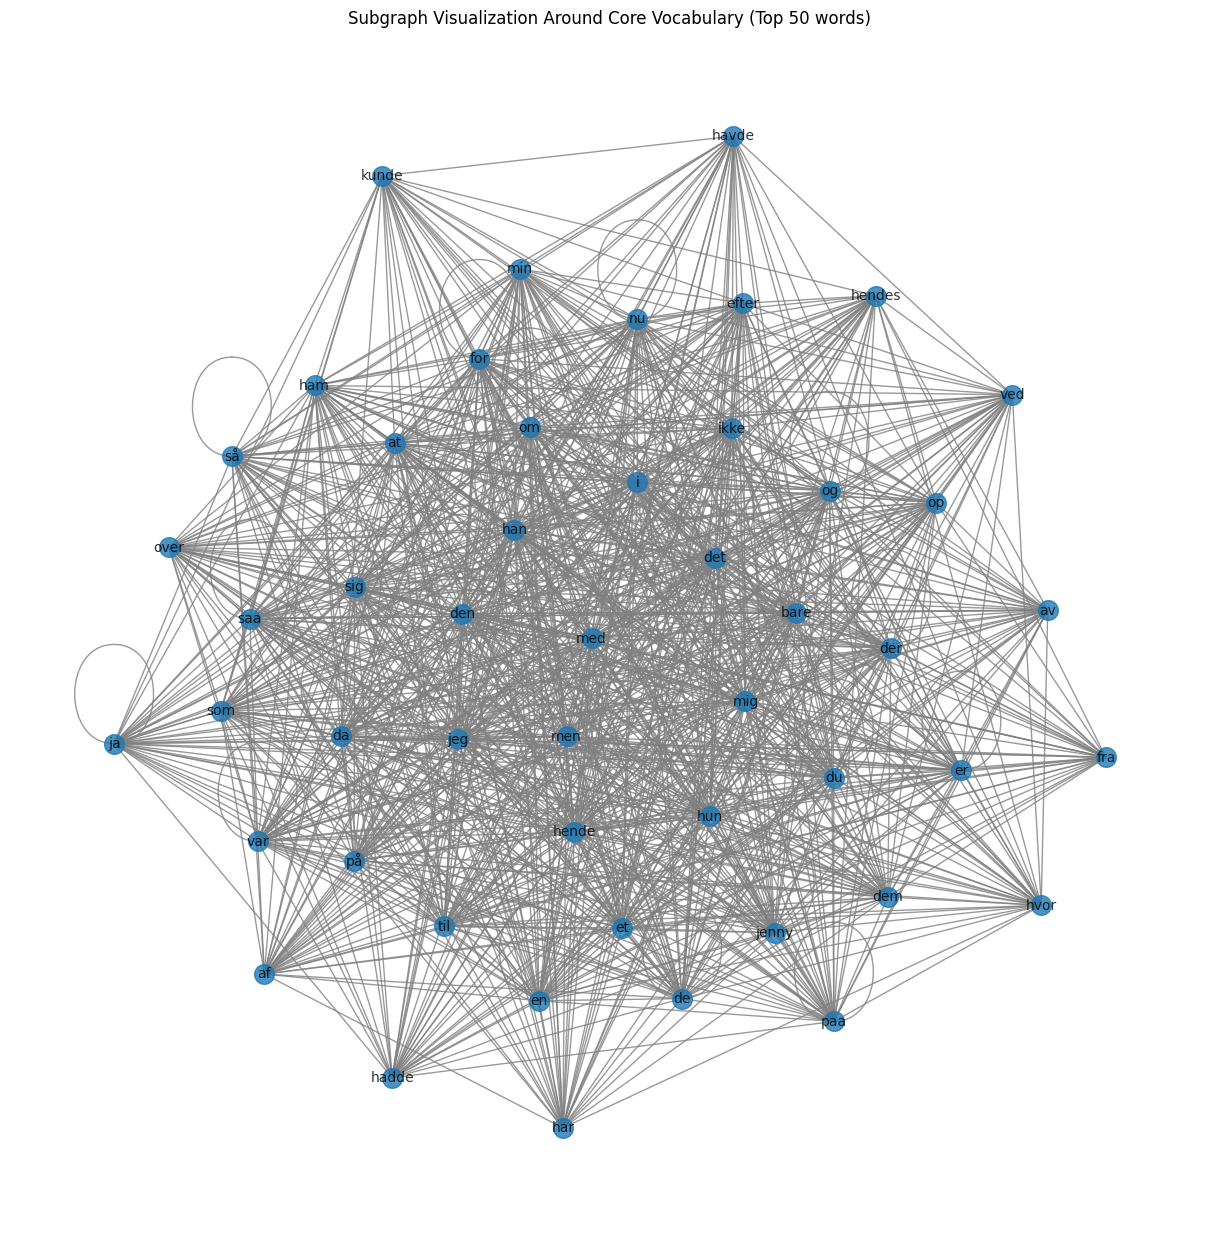

In [57]:
core_words = [word for word, degree in core_vocabulary]

subgraph = G.subgraph(core_words)

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(subgraph, k=0.5)
nx.draw(subgraph, pos, with_labels=True, node_size=200, font_size=10, alpha=0.8, edge_color='gray')
plt.title("Subgraph Visualization Around Core Vocabulary (Top 50 words)")
plt.show()